# Cluster-matrix comparison: TikTok (k=3 RCEGT) vs Instagram (k=4 RCEDTG)

**Files**
- TK: `RFM_TK_rolling_quadrimesters/tk_RCEGT_k3_monthly_cluster_matrix.csv` — 13,249 users × 40 months (2022-12 → 2026-03)
- IG: `RFM_IG_rolling_quadrimesters/Ig_RCEDTG_k4_monthly_cluster_matrix.csv` — 18,752 users × 39 months (2023-01 → 2026-03)

Each cell value is one of: `C1`, `C2`, `C3` (`C4` on IG), `Inactive`, or `Not yet active`.

**Shared calendar window for cross-platform comparison:** `2023-01 → 2026-03` (38 months).

**What this notebook covers**
1. Data loading and label normalisation
2. Activity rate over time (% active vs inactive)
3. Cluster-state composition of active users per month
4. First-activation (debut) timing distribution
5. User-level lifecycle: active span & inactive re-entry rate
6. Cluster loyalty vs volatility (Shannon entropy of each user's state sequence)
7. Transition rate: how often users *switch* cluster vs stay (within active months)
8. Cross-platform overlay — shared-window activity & cluster-composition comparison
9. Survival curves (how long until a user goes permanently inactive)
10. Summary findings


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

BASE = r"D:\Polythecninco di Milano\AFB_Lab\Mickey"
TK_PATH = os.path.join(BASE, "RFM_TK_rolling_quadrimesters", "tk_RCEGT_k3_monthly_cluster_matrix.csv")
IG_PATH = os.path.join(BASE, "RFM_IG_rolling_quadrimesters", "Ig_RCEDTG_k4_monthly_cluster_matrix.csv")
OUT = os.path.join(BASE, "eda_cluster_matrix_outputs")
os.makedirs(OUT, exist_ok=True)
def save(fig, name): fig.savefig(os.path.join(OUT, name), bbox_inches="tight", dpi=130)
print("output ->", OUT)

output -> D:\Polythecninco di Milano\AFB_Lab\Mickey\eda_cluster_matrix_outputs


## 1  Load & normalise

In [2]:
tk_raw = pd.read_csv(TK_PATH)
ig_raw = pd.read_csv(IG_PATH)

ID_COLS = ["user_key", "user_id", "username"]

def make_long(df, platform, k):
    """Wide → long; add canonical 'state' column and period index."""
    month_cols = [c for c in df.columns if c not in ID_COLS]
    long = df[ID_COLS].copy()
    for m in month_cols:
        long[m] = df[m].fillna("Not yet active")
    long = long.melt(id_vars=ID_COLS, var_name="month", value_name="state")
    long["month"] = pd.to_datetime(long["month"], format="%Y-%m")
    long["platform"] = platform
    long["k"] = k
    # canonical state class
    long["state_class"] = long["state"].apply(
        lambda s: "Active" if s.startswith("C") else s)
    return long

tk = make_long(tk_raw, "TK", 3)
ig = make_long(ig_raw, "IG", 4)

SHARED_START = pd.Timestamp("2023-01-01")
SHARED_END   = pd.Timestamp("2026-03-01")

print("TK long:", tk.shape, "| months:", tk.month.nunique(), "|",
      tk.month.min().strftime("%Y-%m"), "->", tk.month.max().strftime("%Y-%m"))
print("IG long:", ig.shape, "| months:", ig.month.nunique(), "|",
      ig.month.min().strftime("%Y-%m"), "->", ig.month.max().strftime("%Y-%m"))
print("Shared window:", SHARED_START.strftime("%Y-%m"), "->", SHARED_END.strftime("%Y-%m"),
      f"({(SHARED_END.year-SHARED_START.year)*12 + SHARED_END.month - SHARED_START.month + 1} months)")

TK long: (529960, 8) | months: 40 | 2022-12 -> 2026-03
IG long: (731328, 8) | months: 39 | 2023-01 -> 2026-03
Shared window: 2023-01 -> 2026-03 (39 months)


In [3]:
# State frequency overview
for name, df in [("TK", tk), ("IG", ig)]:
    counts = df.state.value_counts()
    pcts   = (counts / len(df) * 100).round(1)
    print(f"\n=== {name} state frequencies ===")
    print(pd.DataFrame({"count": counts, "%": pcts}).to_string())


=== TK state frequencies ===
                 count     %
state                       
Inactive        261586  49.4
Not yet active  212074  40.0
C3               47019   8.9
C2                6658   1.3
C1                2623   0.5

=== IG state frequencies ===
                 count     %
state                       
Inactive        448639  61.3
Not yet active  117359  16.0
C3              109819  15.0
C1               31302   4.3
C4               12290   1.7
C2               11919   1.6


## 2  Activity rate over time

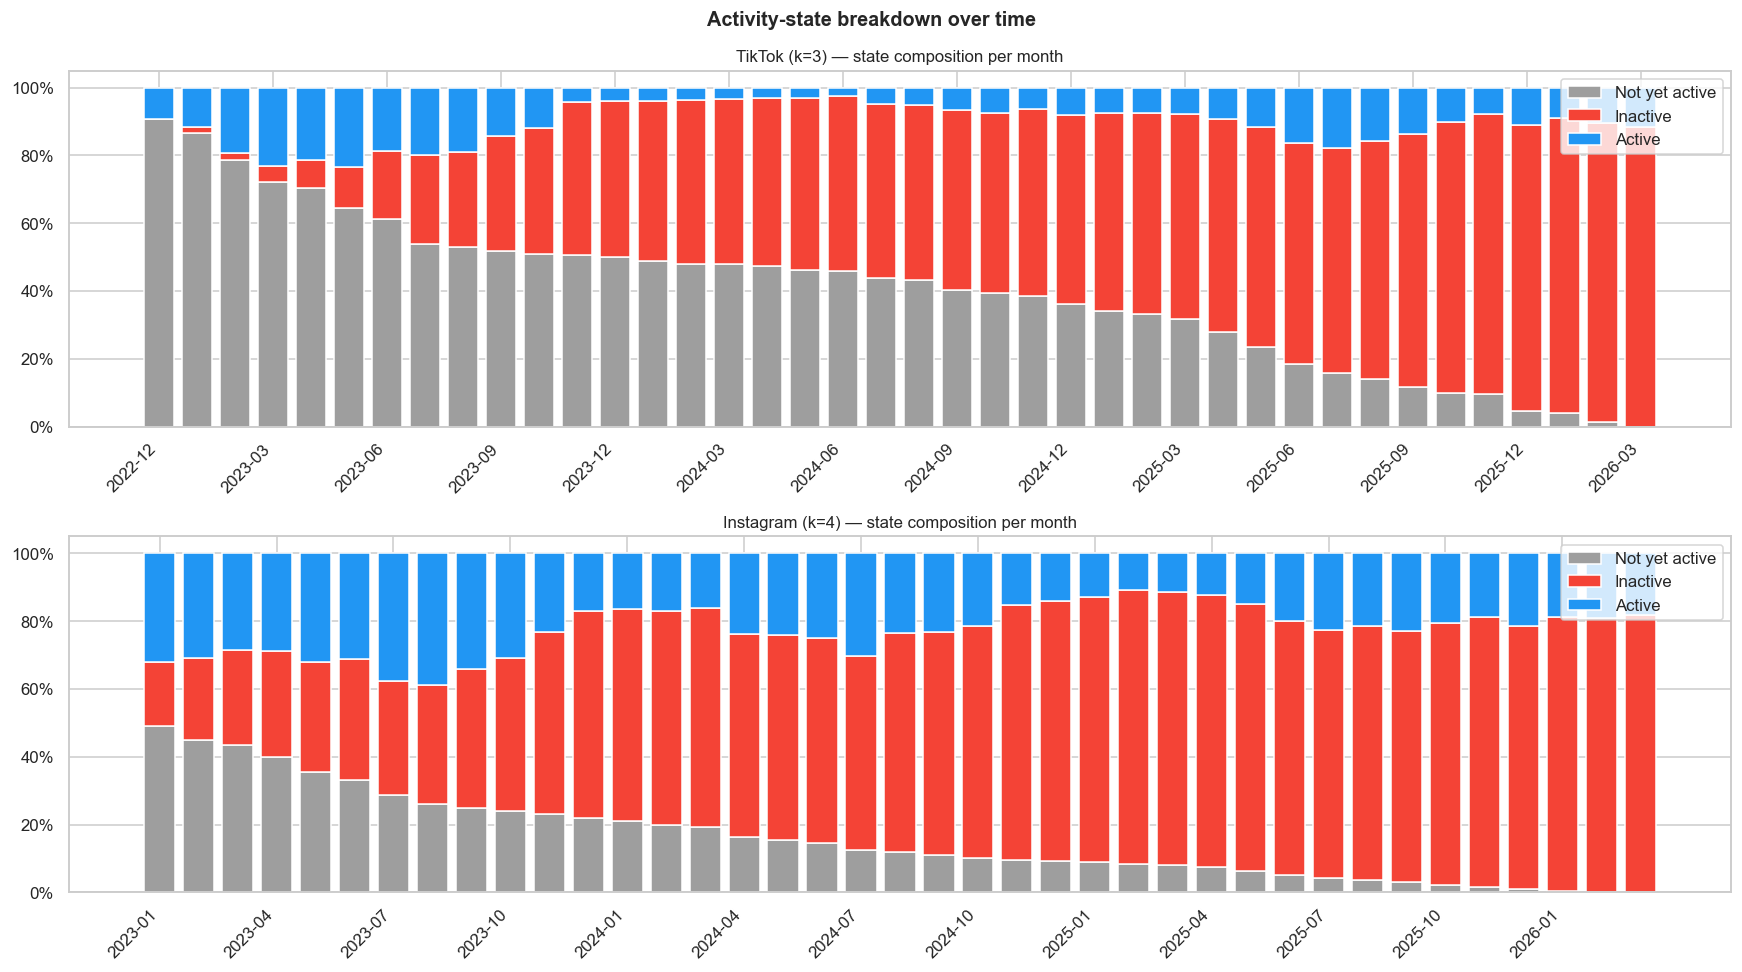

In [4]:
def activity_rate(df):
    g = df.groupby("month")["state_class"].value_counts(normalize=True).unstack(fill_value=0)
    g.index = g.index.to_period("M")
    return g

tk_ar = activity_rate(tk)
ig_ar = activity_rate(ig)

COLORS = {"Active": "#2196F3", "Inactive": "#F44336", "Not yet active": "#9E9E9E"}

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
for ax, (ar, name, k) in zip(axes, [(tk_ar, "TikTok", 3), (ig_ar, "Instagram", 4)]):
    x = np.arange(len(ar))
    bot = np.zeros(len(ar))
    for sc in ["Not yet active", "Inactive", "Active"]:
        if sc in ar.columns:
            ax.bar(x, ar[sc].values, bottom=bot, label=sc, color=COLORS[sc], edgecolor=None)
            bot += ar[sc].values
    ax.set_xticks(x[::3]); ax.set_xticklabels([str(p) for p in ar.index[::3]], rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_title(f"{name} (k={k}) — state composition per month"); ax.legend(loc="upper right")
fig.suptitle("Activity-state breakdown over time", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "01_activity_rate.png"); plt.show()

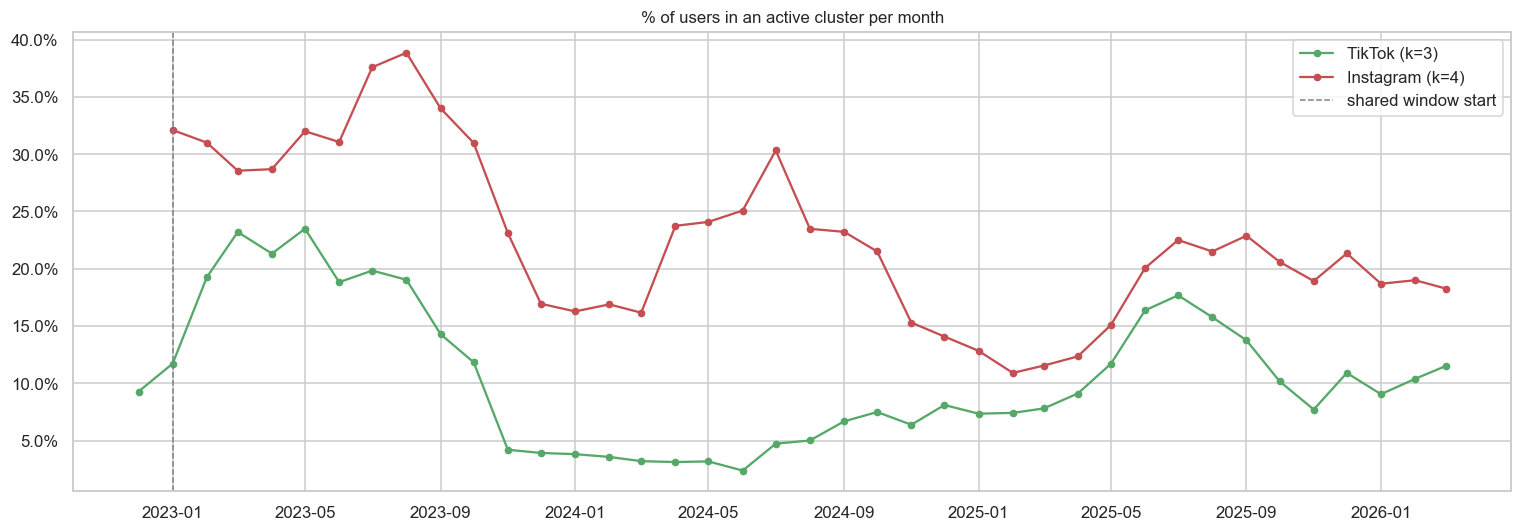

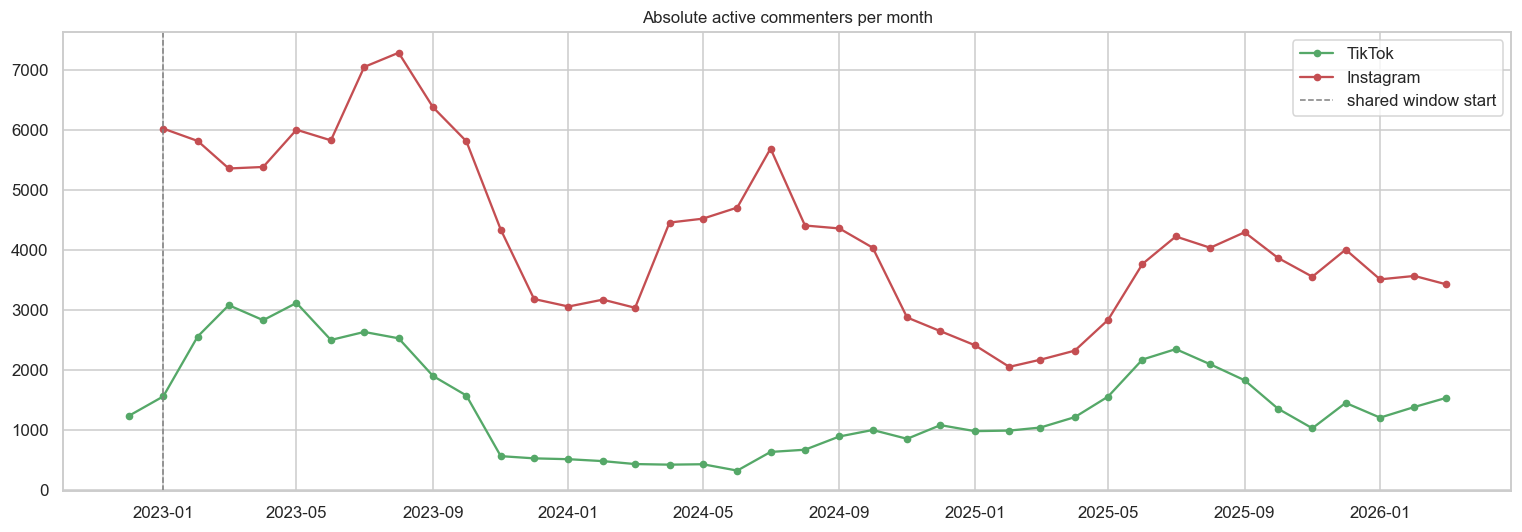

In [5]:
# Line plot of % Active only — easier to compare trend
tk_act = tk.groupby("month")["state_class"].apply(lambda s: (s=="Active").mean())
ig_act = ig.groupby("month")["state_class"].apply(lambda s: (s=="Active").mean())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tk_act.index, tk_act.values, "-o", ms=4, label="TikTok (k=3)", color="#55A868")
ax.plot(ig_act.index, ig_act.values, "-o", ms=4, label="Instagram (k=4)", color="#C44E52")
ax.axvline(SHARED_START, color="gray", ls="--", lw=1, label="shared window start")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title("% of users in an active cluster per month")
ax.legend(); fig.tight_layout(); save(fig, "02_active_pct_line.png"); plt.show()

# Absolute active-user counts
tk_n = tk[tk.state_class=="Active"].groupby("month").size()
ig_n = ig[ig.state_class=="Active"].groupby("month").size()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tk_n.index, tk_n.values, "-o", ms=4, label="TikTok", color="#55A868")
ax.plot(ig_n.index, ig_n.values, "-o", ms=4, label="Instagram", color="#C44E52")
ax.axvline(SHARED_START, color="gray", ls="--", lw=1, label="shared window start")
ax.set_title("Absolute active commenters per month")
ax.legend(); fig.tight_layout(); save(fig, "03_active_count_line.png"); plt.show()

## 3  Cluster-state composition of active users per month

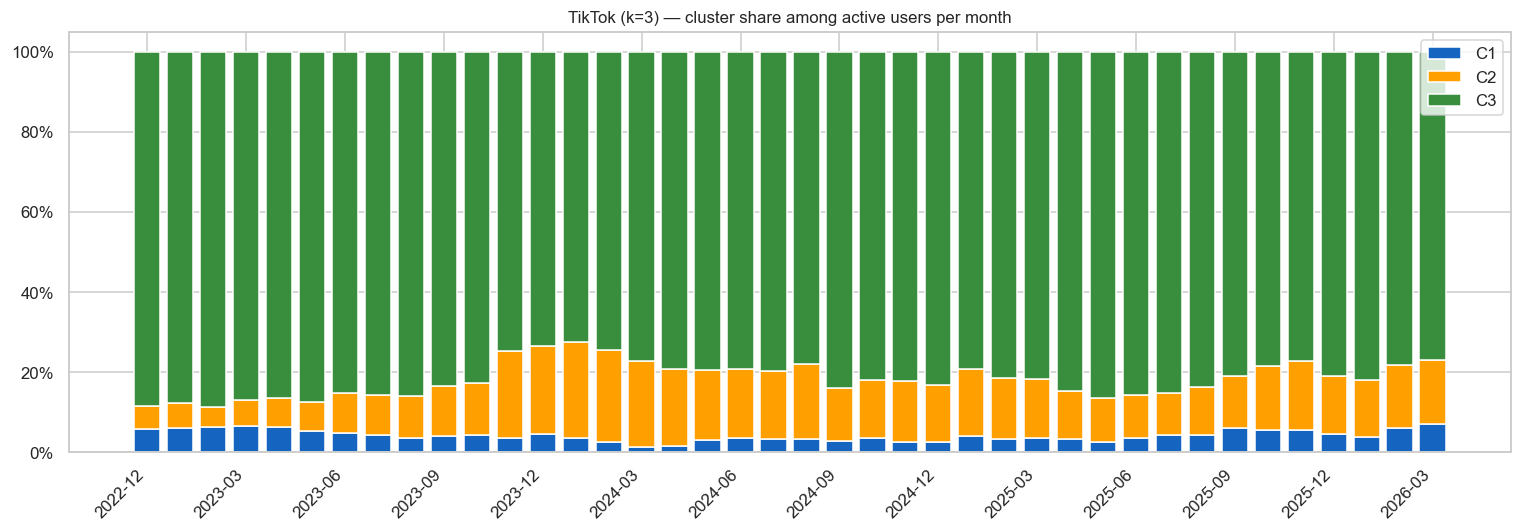

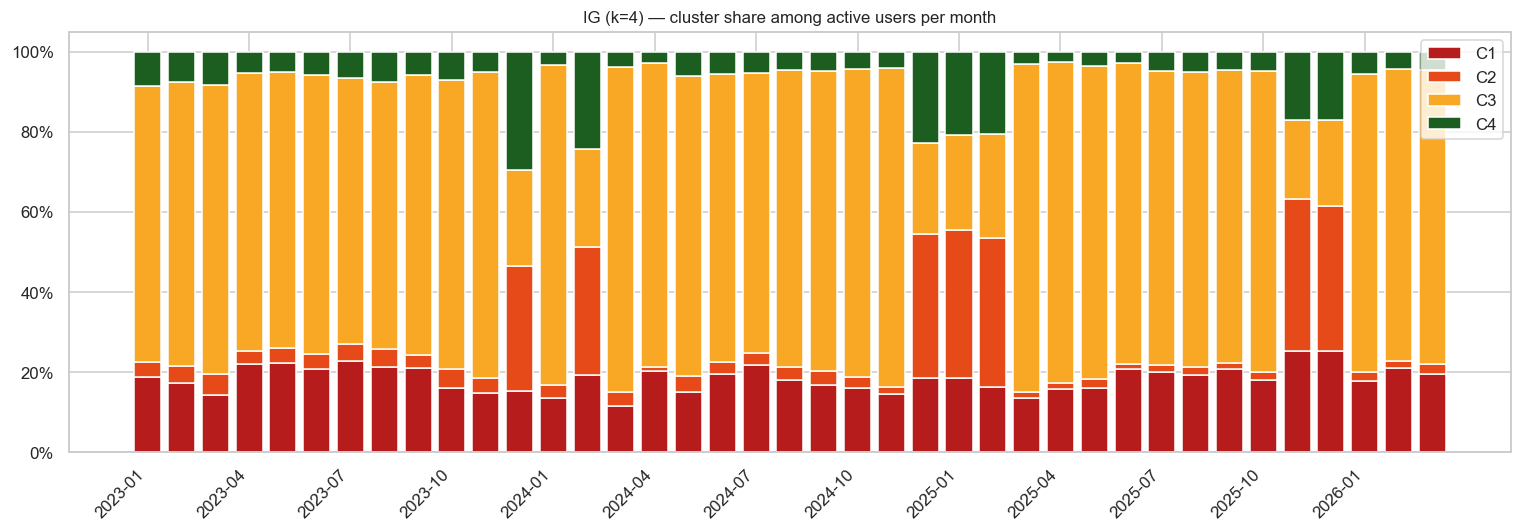

In [6]:
def cluster_share(df, month_filter=None):
    d = df[df.state.str.startswith("C")].copy()
    if month_filter is not None:
        d = d[d.month >= month_filter]
    return d.groupby("month")["state"].value_counts(normalize=True).unstack(fill_value=0)

PALETTES = {
    "TK": {"C1": "#1565C0", "C2": "#FFA000", "C3": "#388E3C"},
    "IG": {"C1": "#B71C1C", "C2": "#E64A19", "C3": "#F9A825", "C4": "#1B5E20"},
}

def plot_cluster_share(cs, name, k, pal, fname):
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(cs)); bot = np.zeros(len(cs))
    clusters = sorted([c for c in cs.columns if c.startswith("C")])
    for c in clusters:
        if c in cs:
            ax.bar(x, cs[c].values, bottom=bot, label=c, color=pal.get(c, "#888"), edgecolor=None)
            bot += cs[c].values
    ax.set_xticks(x[::3]); ax.set_xticklabels([cs.index[i].strftime("%Y-%m")
                                                 for i in range(0, len(cs), 3)], rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_title(f"{name} (k={k}) — cluster share among active users per month")
    ax.legend(loc="upper right"); fig.tight_layout(); save(fig, fname); plt.show()

tk_cs = cluster_share(tk)
ig_cs = cluster_share(ig)
plot_cluster_share(tk_cs, "TikTok", 3, PALETTES["TK"], "04_tk_cluster_share.png")
plot_cluster_share(ig_cs, "IG", 4, PALETTES["IG"], "05_ig_cluster_share.png")

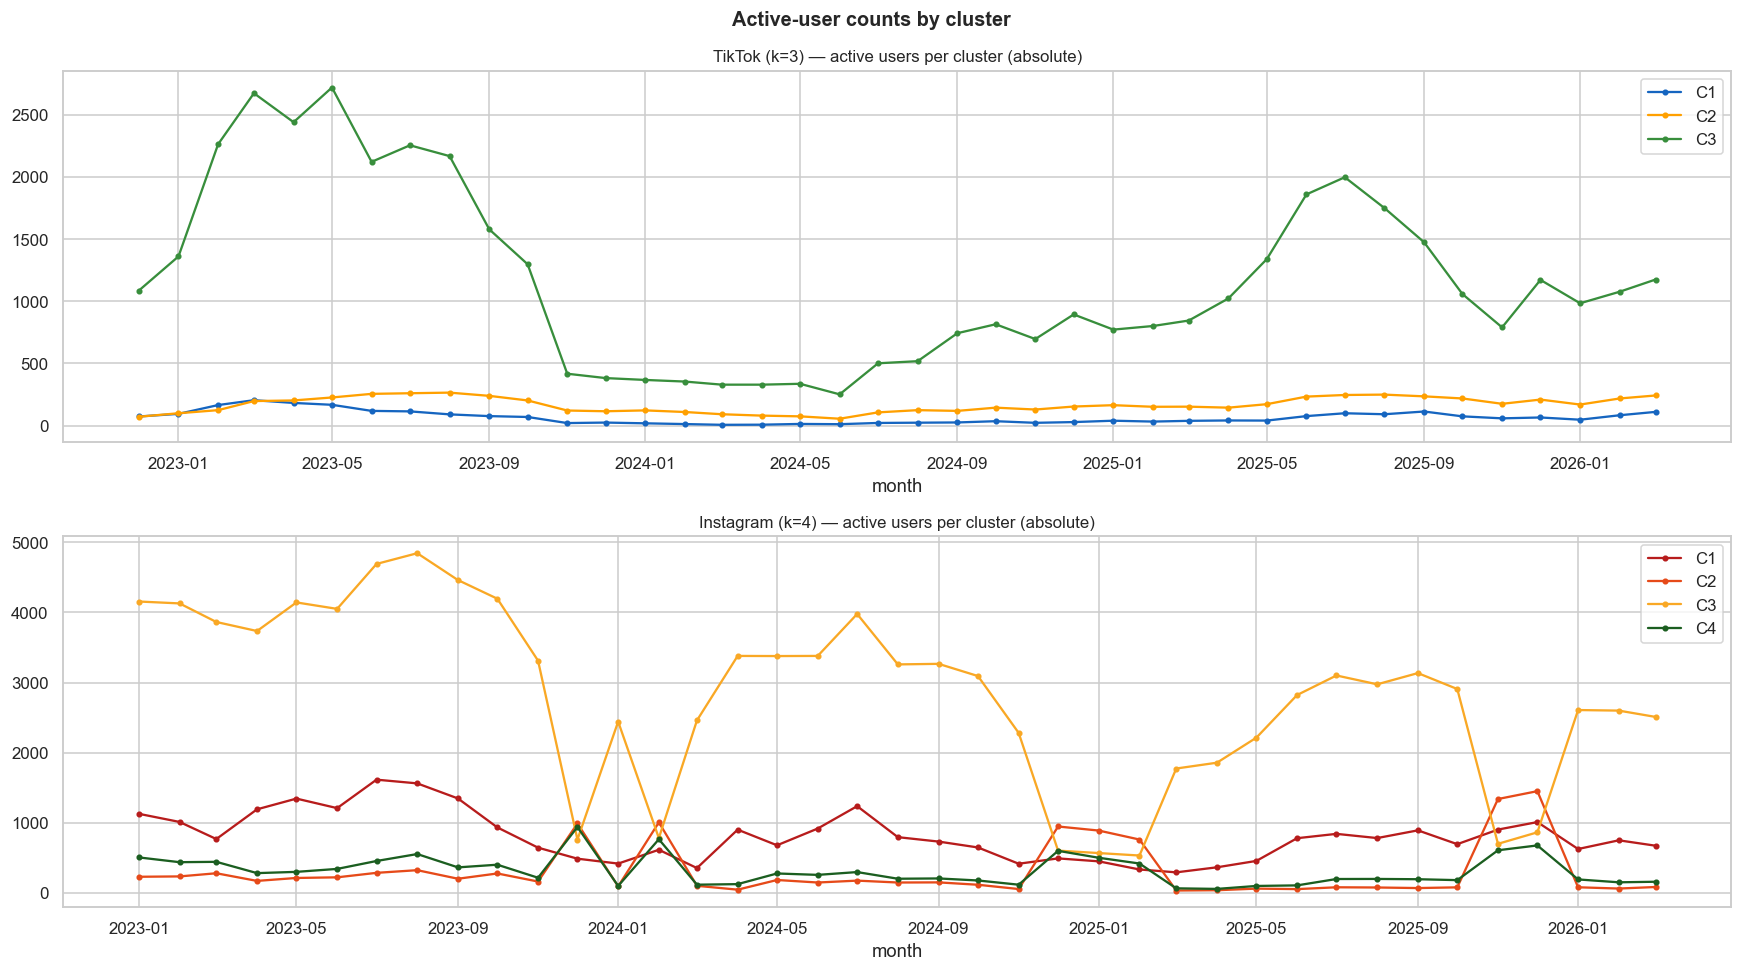

In [7]:
# Absolute count by cluster per month (shows raw engagement volume)
def cluster_count(df):
    return df[df.state.str.startswith("C")].groupby(["month","state"]).size().unstack(fill_value=0)

tk_cc = cluster_count(tk)
ig_cc = cluster_count(ig)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
for ax, (cc, name, pal, k) in zip(axes, [(tk_cc, "TikTok", PALETTES["TK"], 3),
                                          (ig_cc, "Instagram", PALETTES["IG"], 4)]):
    for c in sorted([col for col in cc.columns if col.startswith("C")]):
        ax.plot(cc.index, cc[c], "-o", ms=3, label=c, color=pal.get(c,"#888"))
    ax.set_title(f"{name} (k={k}) — active users per cluster (absolute)")
    ax.legend(); ax.set_xlabel("month")
fig.suptitle("Active-user counts by cluster", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "06_cluster_counts.png"); plt.show()

## 4  First-activation (debut) timing

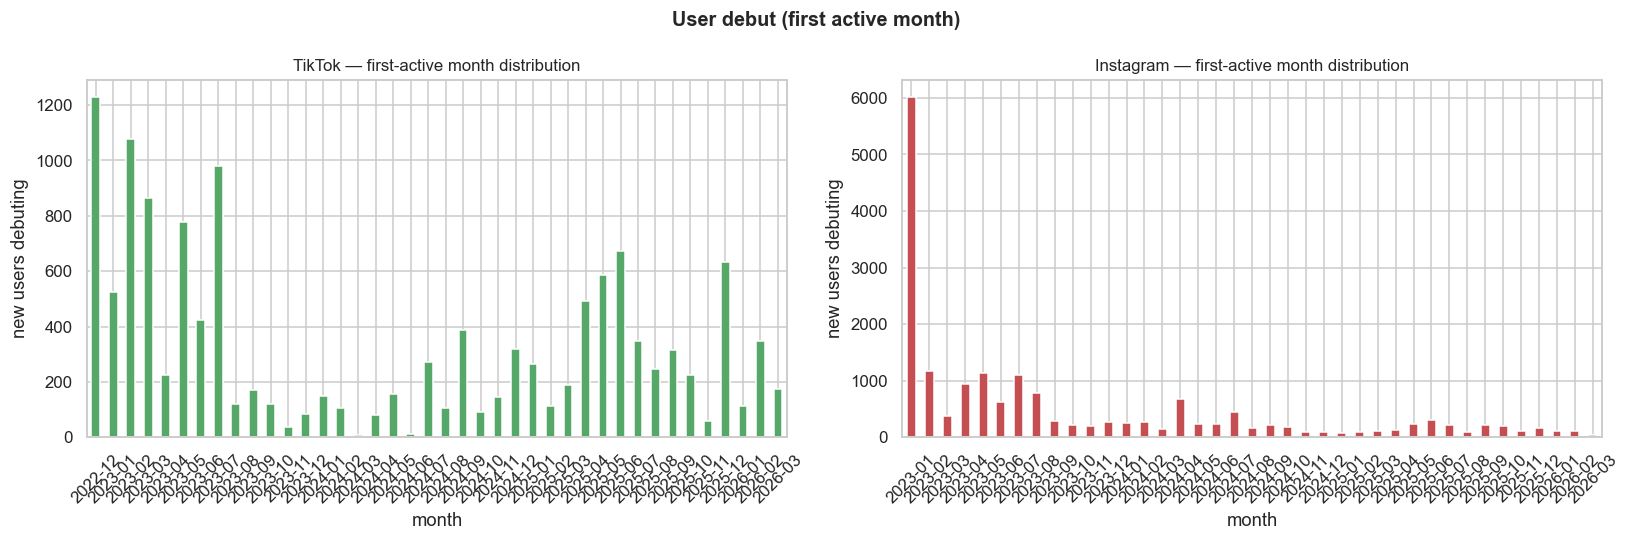

TK debut stats:
count                            13249
mean     2024-04-01 03:42:02.907389440
min                2022-12-01 00:00:00
25%                2023-03-01 00:00:00
50%                2023-12-01 00:00:00
75%                2025-05-01 00:00:00
max                2026-03-01 00:00:00
Name: debut, dtype: object

IG debut stats:
count                            18329
mean     2023-09-07 13:00:36.728681216
min                2023-01-01 00:00:00
25%                2023-01-01 00:00:00
50%                2023-05-01 00:00:00
75%                2024-03-01 00:00:00
max                2026-03-01 00:00:00
Name: debut, dtype: object


In [8]:
def first_active(df, id_col="user_key"):
    active = df[df.state.str.startswith("C")]
    return active.groupby(id_col)["month"].min().rename("debut")

tk_debut = first_active(tk)
ig_debut = first_active(ig)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (d, name, color) in zip(axes, [(tk_debut,"TikTok","#55A868"),(ig_debut,"Instagram","#C44E52")]):
    d.dt.to_period("M").value_counts().sort_index().plot.bar(ax=ax, color=color, edgecolor=None)
    ax.set_title(f"{name} — first-active month distribution")
    ax.set_xlabel("month"); ax.set_ylabel("new users debuting")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("User debut (first active month)", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "07_debut_timing.png"); plt.show()

print("TK debut stats:"); print(tk_debut.describe())
print("\nIG debut stats:"); print(ig_debut.describe())

## 5  Active lifespan & re-entry rate

In [9]:
def lifecycle_stats(df, id_col="user_key"):
    rows = []
    for uid, grp in df.sort_values("month").groupby(id_col):
        states = grp.set_index("month")["state_class"]
        first_active = states[states == "Active"].index.min()
        last_active  = states[states == "Active"].index.max()
        if pd.isna(first_active):
            continue
        total_months = len(states[states.index >= first_active])
        active_months = (states[states.index >= first_active] == "Active").sum()
        inactive_months = (states[states.index >= first_active] == "Inactive").sum()
        # re-entry: went Inactive then Active again
        seq = states[states.index >= first_active].values
        reentry = any(
            seq[i] == "Active" and any(s == "Inactive" for s in seq[:i])
            for i in range(1, len(seq))
        )
        rows.append({
            "user_key": uid,
            "active_months": active_months,
            "inactive_months": inactive_months,
            "observed_span_months": total_months,
            "pct_active": active_months / total_months if total_months else 0,
            "re_entry": int(reentry),
        })
    return pd.DataFrame(rows)

print("Computing TK lifecycle (may take ~20s)…")
tk_lc = lifecycle_stats(tk)
print("Computing IG lifecycle…")
ig_lc = lifecycle_stats(ig)
print("done")

Computing TK lifecycle (may take ~20s)…


Computing IG lifecycle…


done


In [10]:
# Summary stats
for name, lc in [("TikTok", tk_lc), ("Instagram", ig_lc)]:
    print(f"\n=== {name} lifecycle stats ===")
    print(lc[["active_months","inactive_months","observed_span_months","pct_active"]].describe().round(2))
    print(f"Re-entry rate: {lc.re_entry.mean()*100:.1f}%")


=== TikTok lifecycle stats ===
       active_months  inactive_months  observed_span_months  pct_active
count       13249.00         13249.00              13249.00    13249.00
mean            4.25            19.74                 23.99        0.30
std             1.82            13.12                 13.33        0.27
min             1.00             0.00                  1.00        0.02
25%             4.00             7.00                 11.00        0.11
50%             4.00            23.00                 28.00        0.19
75%             4.00            32.00                 37.00        0.40
max            39.00            39.00                 40.00        1.00
Re-entry rate: 6.4%

=== Instagram lifecycle stats ===
       active_months  inactive_months  observed_span_months  pct_active
count       18329.00         18329.00              18329.00    18329.00
mean            9.02            21.76                 30.78        0.34
std             5.84            10.18            

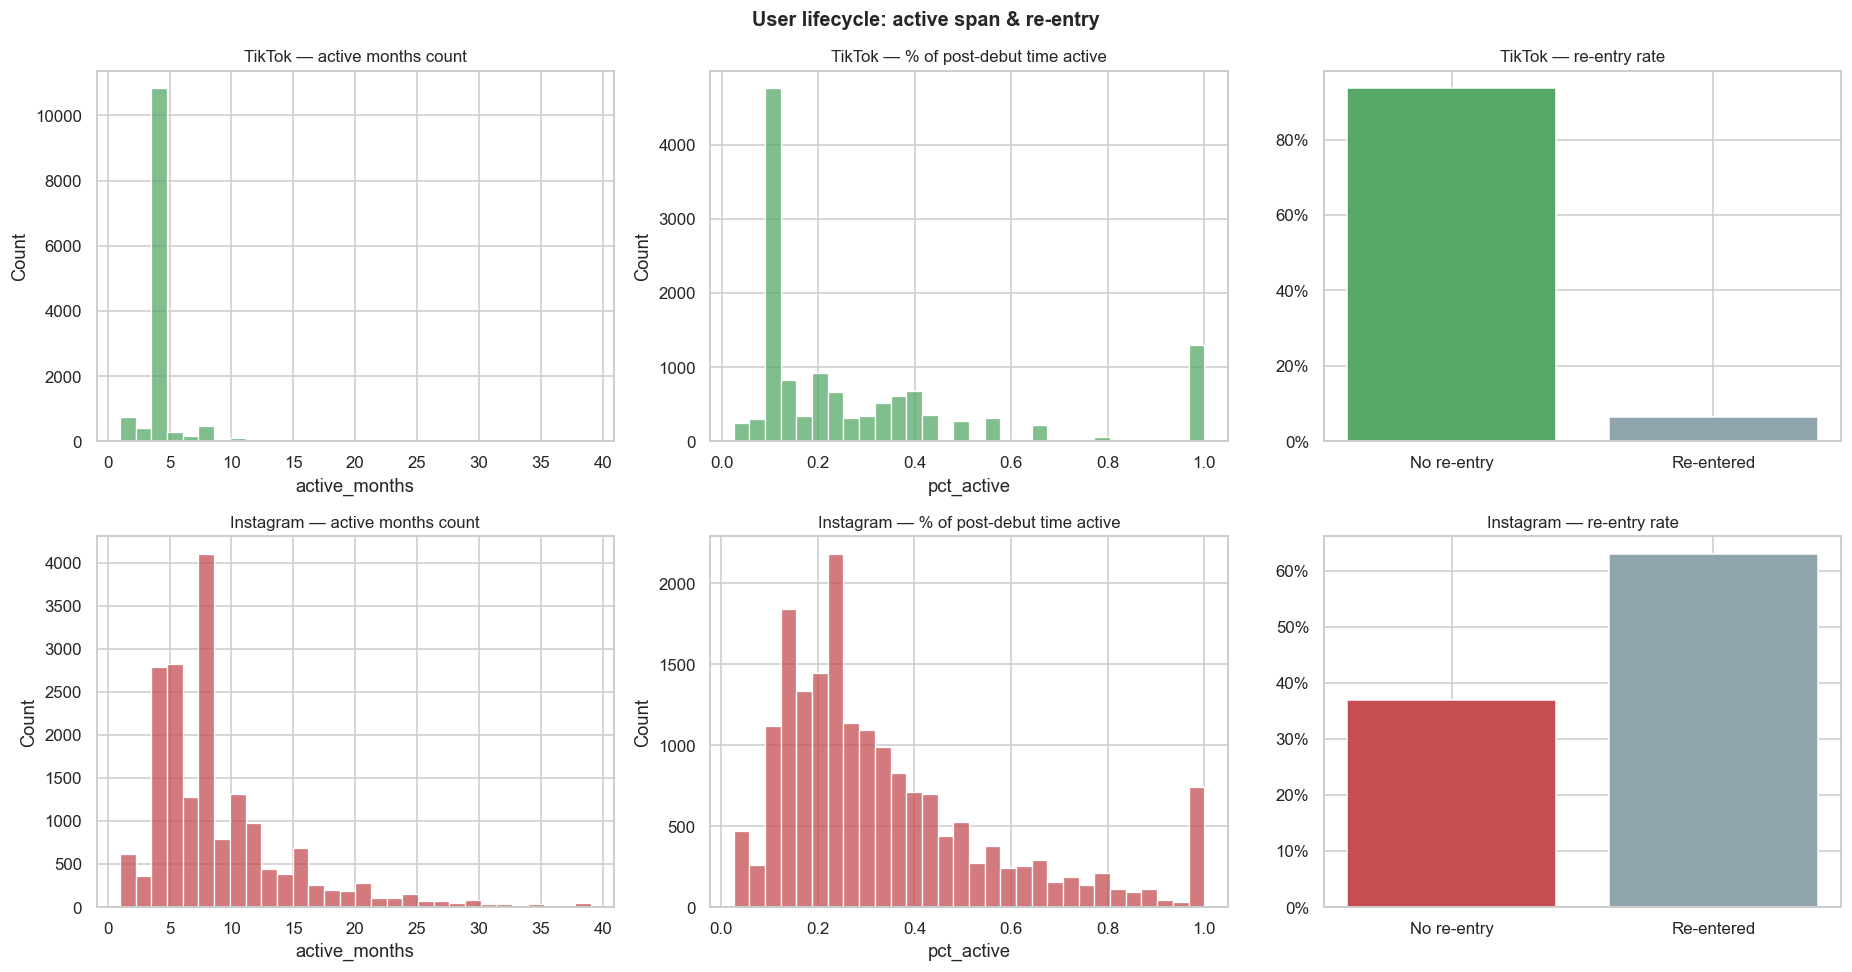

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, (lc, name, color) in enumerate([(tk_lc,"TikTok","#55A868"),(ig_lc,"Instagram","#C44E52")]):
    sns.histplot(lc.active_months, bins=30, ax=axes[row,0], color=color)
    axes[row,0].set_title(f"{name} — active months count")

    sns.histplot(lc.pct_active.clip(0,1), bins=30, ax=axes[row,1], color=color)
    axes[row,1].set_title(f"{name} — % of post-debut time active")

    val = lc.re_entry.value_counts(normalize=True)
    axes[row,2].bar(["No re-entry","Re-entered"], [val.get(0,0), val.get(1,0)], color=[color,"#90A4AE"])
    axes[row,2].yaxis.set_major_formatter(mticker.PercentFormatter(1))
    axes[row,2].set_title(f"{name} — re-entry rate")
fig.suptitle("User lifecycle: active span & re-entry", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "08_lifecycle.png"); plt.show()

## 6  Cluster loyalty vs volatility (Shannon entropy of user state sequences)

In [12]:
from scipy.stats import entropy as shannon_entropy

def user_entropy(df, id_col="user_key"):
    """Shannon entropy of cluster assignments for each user (active months only)."""
    rows = []
    for uid, grp in df.groupby(id_col):
        active = grp[grp.state.str.startswith("C")]["state"].values
        if len(active) == 0:
            continue
        counts = pd.Series(active).value_counts()
        ent = shannon_entropy(counts.values, base=2)
        rows.append({"user_key": uid, "entropy": ent, "active_months": len(active),
                     "n_unique_clusters": counts.shape[0]})
    return pd.DataFrame(rows)

print("Computing entropy…")
tk_ent = user_entropy(tk)
ig_ent = user_entropy(ig)
print("done")

Computing entropy…


done


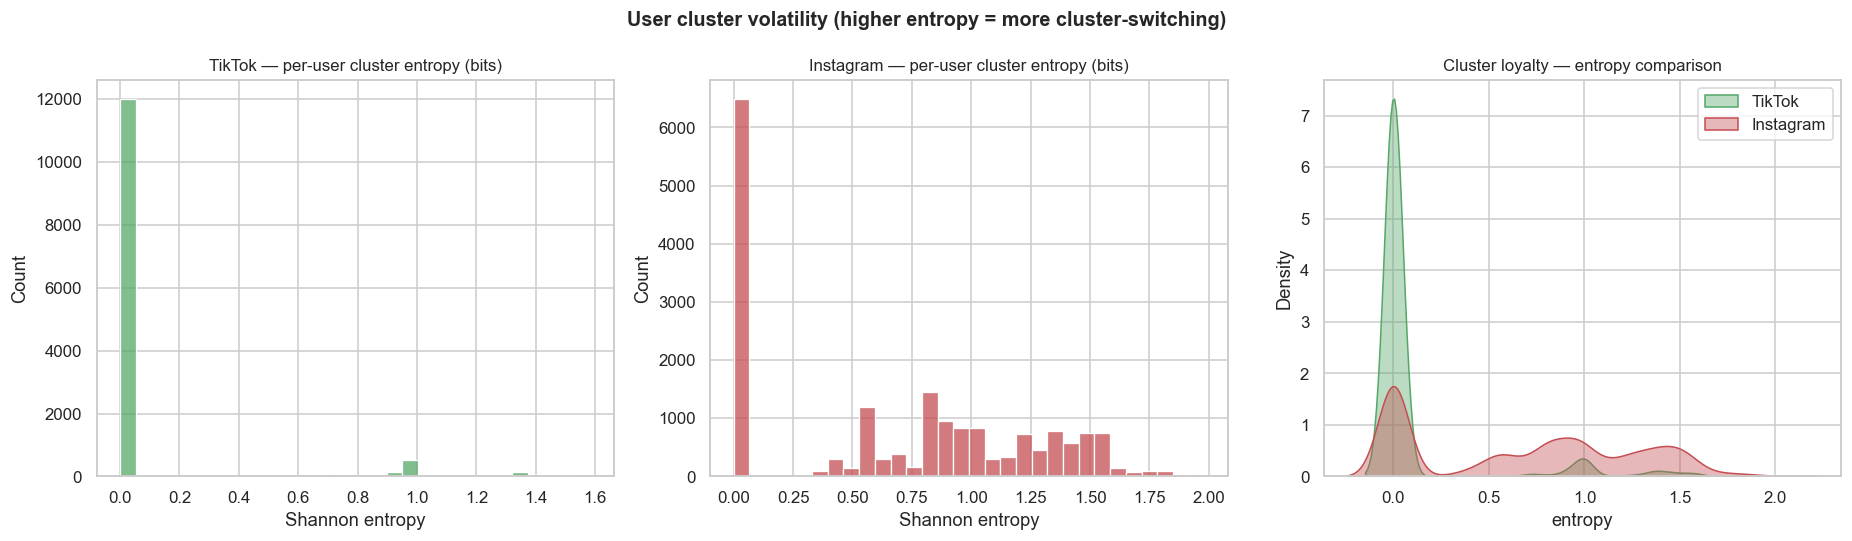

TikTok entropy: mean=0.102 median=0.000  single-cluster users: 90.8%
Instagram entropy: mean=0.673 median=0.811  single-cluster users: 35.4%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (e, name, color) in zip(axes[:2], [(tk_ent,"TikTok","#55A868"),(ig_ent,"Instagram","#C44E52")]):
    sns.histplot(e.entropy, bins=30, ax=ax, color=color)
    ax.set_title(f"{name} — per-user cluster entropy (bits)")
    ax.set_xlabel("Shannon entropy")

# Overlay comparison
ax = axes[2]
sns.kdeplot(tk_ent.entropy, ax=ax, label="TikTok", fill=True, alpha=.4, color="#55A868")
sns.kdeplot(ig_ent.entropy, ax=ax, label="Instagram", fill=True, alpha=.4, color="#C44E52")
ax.set_title("Cluster loyalty — entropy comparison"); ax.legend()
fig.suptitle("User cluster volatility (higher entropy = more cluster-switching)", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "09_entropy.png"); plt.show()

for name, e in [("TikTok", tk_ent), ("Instagram", ig_ent)]:
    print(f"{name} entropy: mean={e.entropy.mean():.3f} median={e.entropy.median():.3f}"
          f"  single-cluster users: {(e.n_unique_clusters==1).mean()*100:.1f}%")

## 7  Month-over-month transition rate (within active users)

In [14]:
def transition_rate(df, id_col="user_key"):
    """For consecutive active months of a user, compute fraction where cluster changed."""
    rows = []
    for uid, grp in df.sort_values("month").groupby(id_col):
        active = grp[grp.state.str.startswith("C")][["month","state"]].sort_values("month")
        if len(active) < 2:
            continue
        states = active.state.values
        months = active.month.values
        for i in range(1, len(states)):
            changed = int(states[i] != states[i-1])
            rows.append({"user_key": uid, "month": months[i], "changed": changed})
    return pd.DataFrame(rows)

print("Computing transitions…")
tk_tr = transition_rate(tk)
ig_tr = transition_rate(ig)
print("done")

Computing transitions…


done


TikTok overall cluster-switch rate: 4.6%
Instagram overall cluster-switch rate: 26.8%


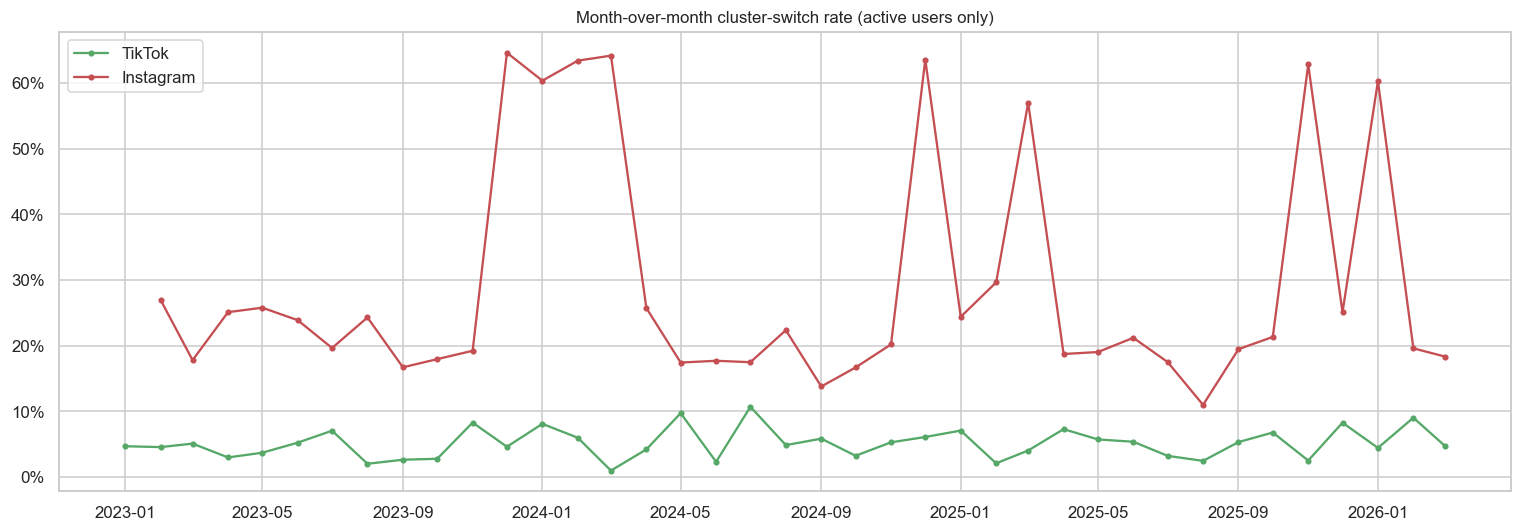

In [15]:
# Overall rate
for name, tr in [("TikTok",tk_tr),("Instagram",ig_tr)]:
    print(f"{name} overall cluster-switch rate: {tr.changed.mean()*100:.1f}%")

# Per-month switch rate
tk_tr_m = tk_tr.groupby("month")["changed"].mean()
ig_tr_m = ig_tr.groupby("month")["changed"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tk_tr_m.index, tk_tr_m.values, "-o", ms=3, label="TikTok", color="#55A868")
ax.plot(ig_tr_m.index, ig_tr_m.values, "-o", ms=3, label="Instagram", color="#C44E52")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title("Month-over-month cluster-switch rate (active users only)")
ax.legend(); fig.tight_layout(); save(fig, "10_switch_rate.png"); plt.show()

## 8  Cross-platform overlay — shared window (2023-01 → 2026-03)

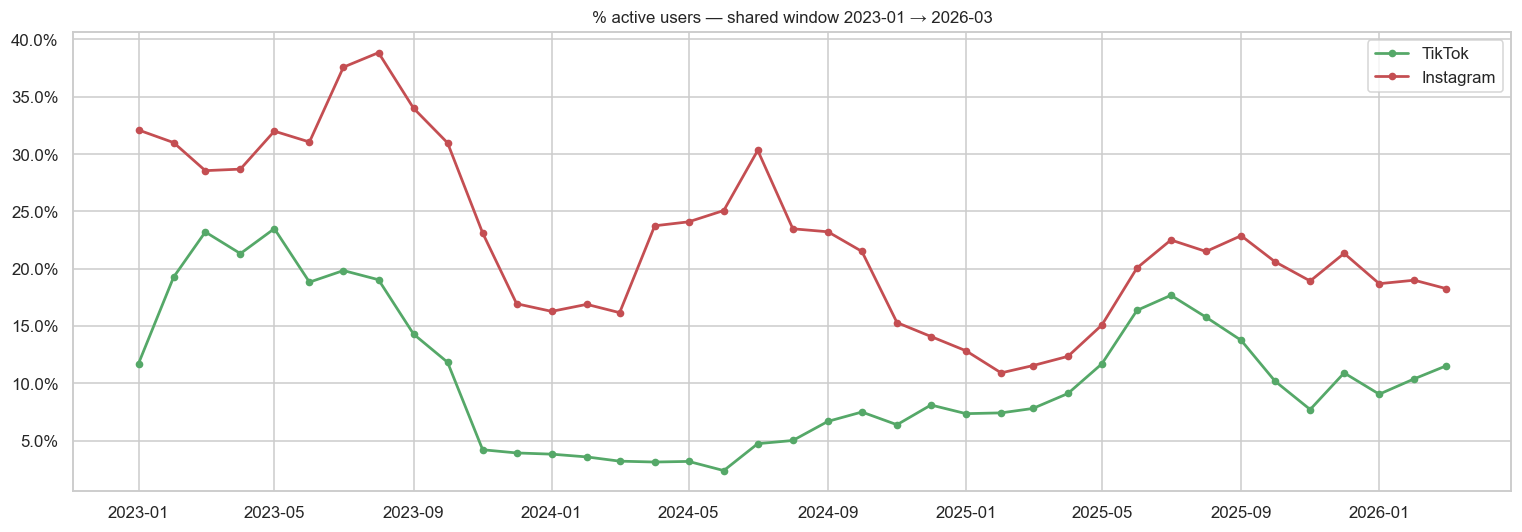

Activity-rate co-movement (shared window, n=39 months):
  Pearson  r=+0.568  p=0.0002
  Spearman ρ=+0.443  p=0.0048
  Detrended Spearman ρ=+0.463  p=0.0034


In [16]:
tk_sh = tk[tk.month.between(SHARED_START, SHARED_END)]
ig_sh = ig[ig.month.between(SHARED_START, SHARED_END)]

# % active in shared window
tk_act_sh = tk_sh.groupby("month")["state_class"].apply(lambda s: (s=="Active").mean())
ig_act_sh = ig_sh.groupby("month")["state_class"].apply(lambda s: (s=="Active").mean())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tk_act_sh.index, tk_act_sh.values, "-o", ms=4, lw=1.8, label="TikTok", color="#55A868")
ax.plot(ig_act_sh.index, ig_act_sh.values, "-o", ms=4, lw=1.8, label="Instagram", color="#C44E52")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title("% active users — shared window 2023-01 → 2026-03")
ax.legend(); fig.tight_layout(); save(fig, "11_shared_active_pct.png"); plt.show()

# Pearson & Spearman correlation of the two activity-rate time series
pr, pp = stats.pearsonr(tk_act_sh, ig_act_sh)
sr, sp = stats.spearmanr(tk_act_sh, ig_act_sh)
print(f"Activity-rate co-movement (shared window, n={len(tk_act_sh)} months):")
print(f"  Pearson  r={pr:+.3f}  p={pp:.4f}")
print(f"  Spearman ρ={sr:+.3f}  p={sp:.4f}")

# Detrended (first-difference)
d_tk = tk_act_sh.diff().dropna()
d_ig = ig_act_sh.diff().dropna()
sr_d, sp_d = stats.spearmanr(d_tk, d_ig)
print(f"  Detrended Spearman ρ={sr_d:+.3f}  p={sp_d:.4f}")

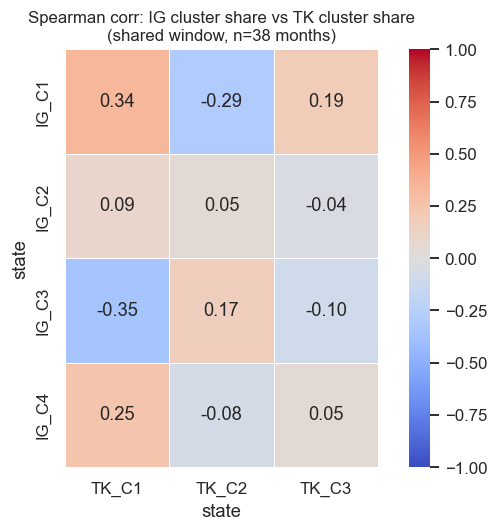

In [17]:
# Heatmap of cluster-share time series correlation (IG cluster vs TK cluster over shared months)
tk_csh = tk_sh[tk_sh.state.str.startswith("C")].groupby(["month","state"]).size().unstack(fill_value=0)
ig_csh = ig_sh[ig_sh.state.str.startswith("C")].groupby(["month","state"]).size().unstack(fill_value=0)
# Normalise to shares within each platform-month
tk_csh_pct = tk_csh.div(tk_csh.sum(axis=1), axis=0).add_prefix("TK_")
ig_csh_pct = ig_csh.div(ig_csh.sum(axis=1), axis=0).add_prefix("IG_")
cross_cs = tk_csh_pct.join(ig_csh_pct, how="inner").corr(method="spearman")
ig_labs = [c for c in cross_cs.index if c.startswith("IG_")]
tk_labs = [c for c in cross_cs.columns if c.startswith("TK_")]
sub = cross_cs.loc[ig_labs, tk_labs]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sub, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=.5, square=True, ax=ax)
ax.set_title("Spearman corr: IG cluster share vs TK cluster share\n(shared window, n=38 months)")
fig.tight_layout(); save(fig, "12_cross_cluster_share_corr.png"); plt.show()

## 8b  Change-in-cluster-share: C1/C2/C3 — visualisation & correlation

For each month we compute the **share of active users** in each of the first 3 clusters (C1, C2, C3 — present on both platforms). We then take **month-over-month first differences** of those shares, giving a ΔC1, ΔC2, ΔC3 time series for each platform.

This answers:
- Do the two platforms' cluster compositions *move together* (raw shares)?
- Do *shocks* to each cluster (first differences, trend removed) co-move across platforms?
- Which cluster pairs are most tightly linked?

In [18]:
# ── Build monthly cluster-share series (C1/C2/C3 only) in shared window ──────
CLUSTERS = ["C1", "C2", "C3"]

def cluster_share_series(df):
    """Monthly share of active users per cluster (shared window, C1-C3 only)."""
    d = df[df.month.between(SHARED_START, SHARED_END) & df.state.str.startswith("C")].copy()
    total = d.groupby("month").size().rename("total")
    g = d.groupby(["month", "state"]).size().unstack(fill_value=0)
    for c in CLUSTERS:
        if c not in g.columns:
            g[c] = 0
    return g[CLUSTERS].div(total, axis=0)   # share within active users

tk_share = cluster_share_series(tk).add_prefix("TK_")
ig_share = cluster_share_series(ig).add_prefix("IG_")

shares = tk_share.join(ig_share, how="inner")
print("Aligned share matrix:", shares.shape, "| months:", shares.index[0].strftime("%Y-%m"),
      "->", shares.index[-1].strftime("%Y-%m"))
shares.round(3).head()

Aligned share matrix: (39, 6) | months: 2023-01 -> 2026-03


state,TK_C1,TK_C2,TK_C3,IG_C1,IG_C2,IG_C3
month,,,,,,
2023-01-01,0.060,0.064,0.876,0.187,0.038,0.690
2023-02-01,0.065,0.049,0.887,0.174,0.040,0.710
2023-03-01,0.066,0.064,0.870,0.143,0.052,0.722
2023-04-01,0.064,0.072,0.864,0.222,0.032,0.694
2023-05-01,0.054,0.073,0.874,0.224,0.035,0.690


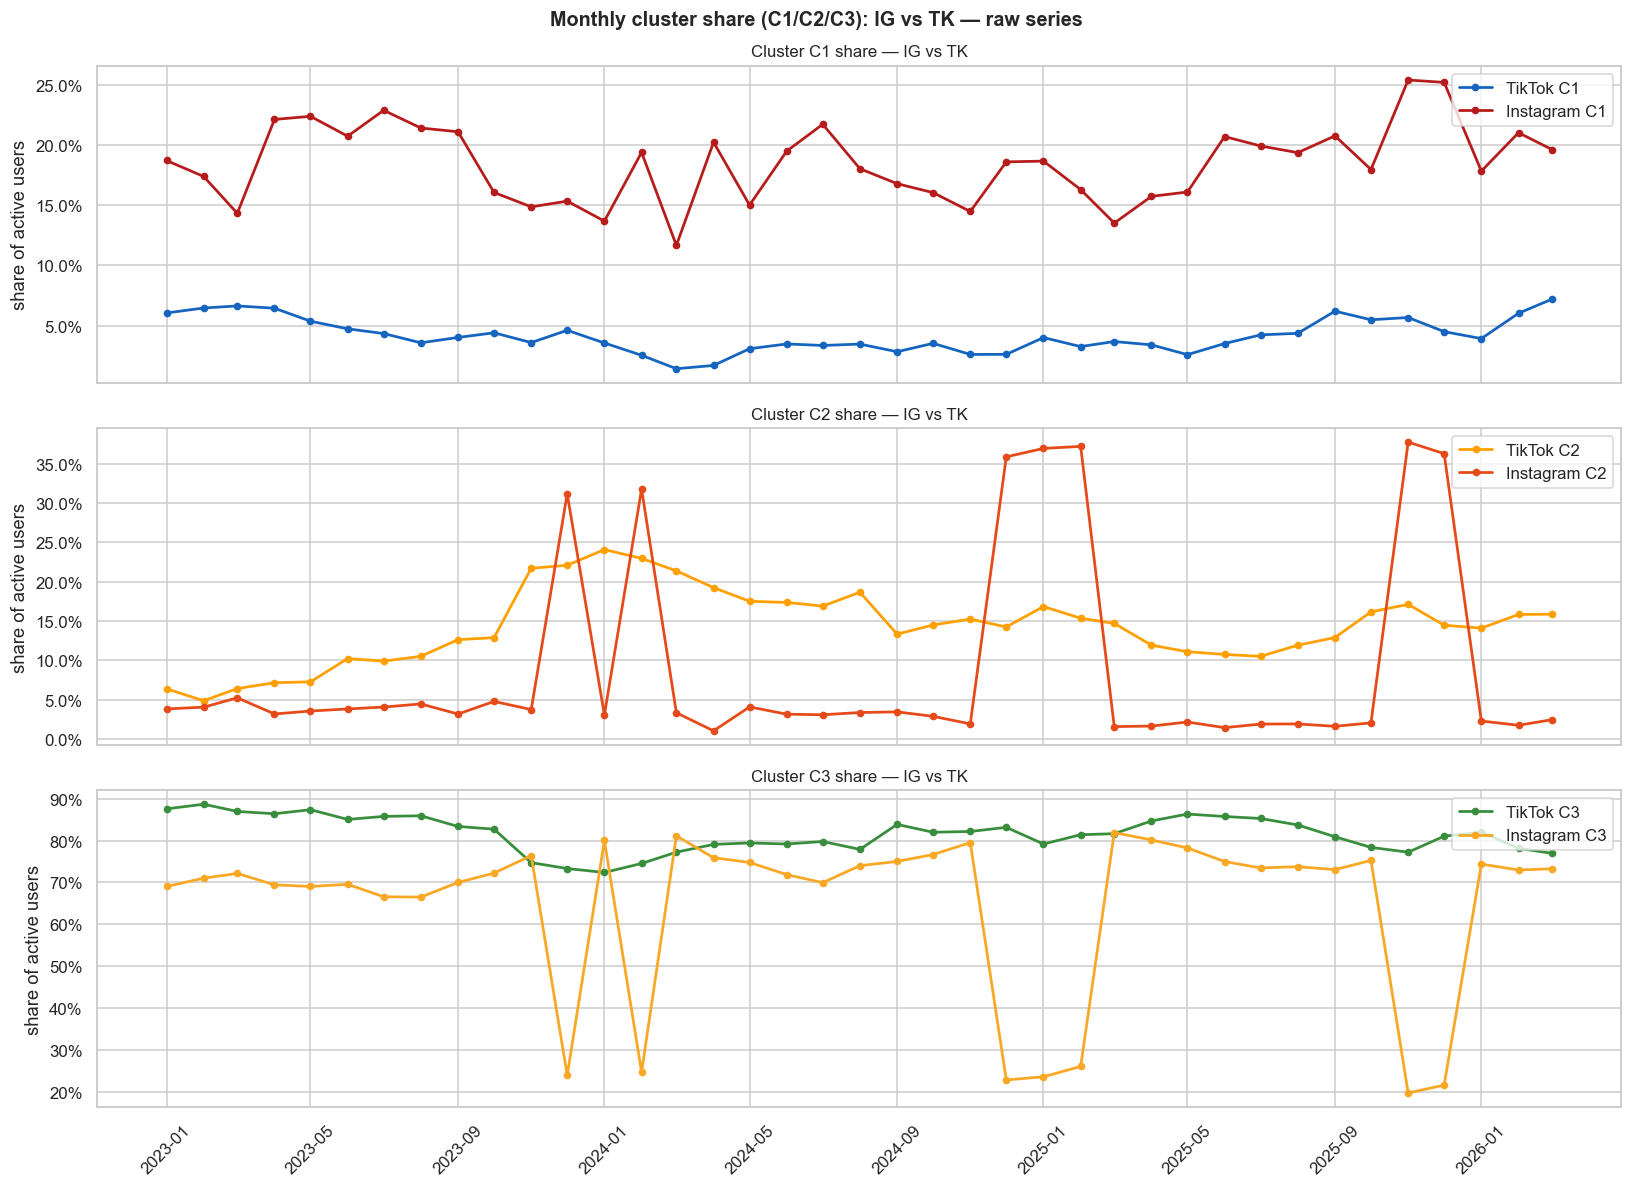

In [19]:
# ── Plot 1: Raw cluster shares over time (IG vs TK, one panel per cluster) ───
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
for ax, c in zip(axes, CLUSTERS):
    ax.plot(shares.index, shares[f"TK_{c}"], "-o", ms=4, lw=1.8,
            label=f"TikTok {c}", color=PALETTES["TK"][c])
    ax.plot(shares.index, shares[f"IG_{c}"], "-o", ms=4, lw=1.8,
            label=f"Instagram {c}", color=PALETTES["IG"][c])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_ylabel("share of active users")
    ax.set_title(f"Cluster {c} share — IG vs TK")
    ax.legend(loc="upper right")

axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Monthly cluster share (C1/C2/C3): IG vs TK — raw series",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "14_cluster_share_raw_series.png")
plt.show()

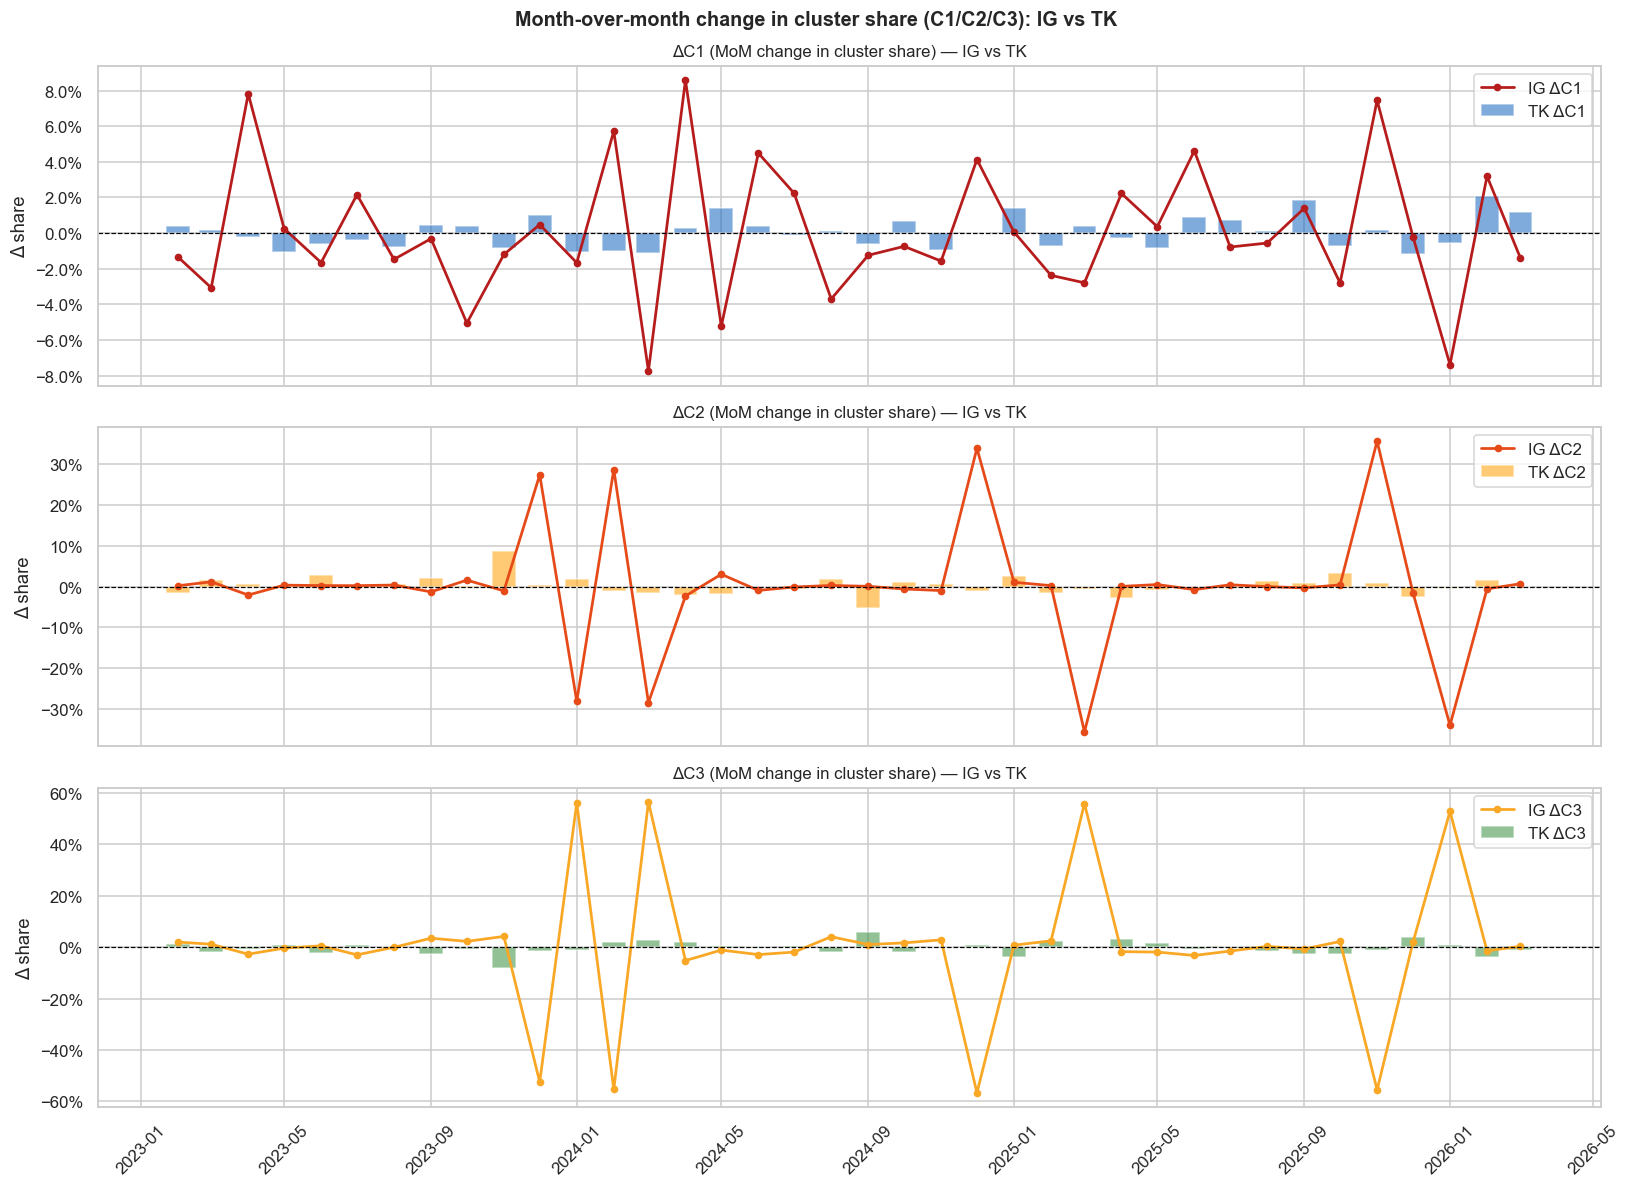

In [20]:
# ── First differences (month-over-month change in share) ─────────────────────
diffs = shares.diff().dropna()
diffs.columns = [c.replace("_", "_Δ", 1) for c in diffs.columns]   # TK_ΔC1, IG_ΔC1, …

# ── Plot 2: Change series (bar for TK, line for IG) one panel per cluster ────
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
for ax, c in zip(axes, CLUSTERS):
    tk_col = f"TK_Δ{c}"
    ig_col = f"IG_Δ{c}"
    ax.bar(diffs.index, diffs[tk_col], width=20, alpha=0.55,
           label=f"TK Δ{c}", color=PALETTES["TK"][c])
    ax.plot(diffs.index, diffs[ig_col], "-o", ms=4, lw=1.8,
            label=f"IG Δ{c}", color=PALETTES["IG"][c])
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_ylabel("Δ share")
    ax.set_title(f"Δ{c} (MoM change in cluster share) — IG vs TK")
    ax.legend(loc="upper right")

axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Month-over-month change in cluster share (C1/C2/C3): IG vs TK",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "15_cluster_share_diff_series.png")
plt.show()

In [21]:
# ── Correlation tables: raw shares & first differences ───────────────────────
from scipy.stats import pearsonr, spearmanr

tk_diff_cols = [f"TK_Δ{c}" for c in CLUSTERS]
ig_diff_cols = [f"IG_Δ{c}" for c in CLUSTERS]
tk_raw_cols  = [f"TK_{c}"  for c in CLUSTERS]
ig_raw_cols  = [f"IG_{c}"  for c in CLUSTERS]

def corr_table(a_df, a_cols, b_df, b_cols, n):
    rows = []
    for ac in a_cols:
        for bc in b_cols:
            pr, pp = pearsonr(a_df[ac], b_df[bc])
            sr, sp = spearmanr(a_df[ac], b_df[bc])
            rows.append({"IG_col": ac, "TK_col": bc,
                         "pearson_r": round(pr, 3), "pearson_p": round(pp, 4),
                         "spearman_rho": round(sr, 3), "spearman_p": round(sp, 4)})
    return pd.DataFrame(rows)

# raw shares
raw_corr = corr_table(shares[ig_raw_cols], ig_raw_cols,
                       shares[tk_raw_cols], tk_raw_cols, len(shares))
# first differences
diff_corr = corr_table(diffs[ig_diff_cols], ig_diff_cols,
                        diffs[tk_diff_cols], tk_diff_cols, len(diffs))

print(f"=== Raw share correlations (n={len(shares)} months) ===")
display(raw_corr.sort_values("spearman_rho", key=abs, ascending=False))
print(f"\n=== First-difference correlations (n={len(diffs)} months, trend removed) ===")
display(diff_corr.sort_values("spearman_rho", key=abs, ascending=False))

=== Raw share correlations (n=39 months) ===


,IG_col,TK_col,pearson_r,pearson_p,spearman_rho,spearman_p
6,IG_C3,TK_C1,-0.004,0.9801,-0.354,0.0269
0,IG_C1,TK_C1,0.355,0.0265,0.341,0.0334
1,IG_C1,TK_C2,-0.293,0.0705,-0.293,0.0699
2,IG_C1,TK_C3,0.210,0.1985,0.190,0.2475
7,IG_C3,TK_C2,-0.228,0.1628,0.168,0.3072
8,IG_C3,TK_C3,0.258,0.1130,-0.098,0.5513
3,IG_C2,TK_C1,-0.072,0.6644,0.094,0.5687
4,IG_C2,TK_C2,0.289,0.0739,0.049,0.7652
5,IG_C2,TK_C3,-0.302,0.0620,-0.036,0.8257



=== First-difference correlations (n=38 months, trend removed) ===


,IG_col,TK_col,pearson_r,pearson_p,spearman_rho,spearman_p
6,IG_ΔC3,TK_ΔC1,-0.182,0.2735,-0.264,0.1098
7,IG_ΔC3,TK_ΔC2,0.037,0.8254,0.246,0.1371
3,IG_ΔC2,TK_ΔC1,0.162,0.3315,0.181,0.2766
0,IG_ΔC1,TK_ΔC1,0.156,0.3487,0.175,0.2928
8,IG_ΔC3,TK_ΔC3,0.031,0.8542,-0.147,0.3794
1,IG_ΔC1,TK_ΔC2,-0.080,0.6333,-0.117,0.4835
5,IG_ΔC2,TK_ΔC3,-0.056,0.7371,-0.087,0.6045
2,IG_ΔC1,TK_ΔC3,0.017,0.9171,0.069,0.6804
4,IG_ΔC2,TK_ΔC2,-0.001,0.9944,0.042,0.8017


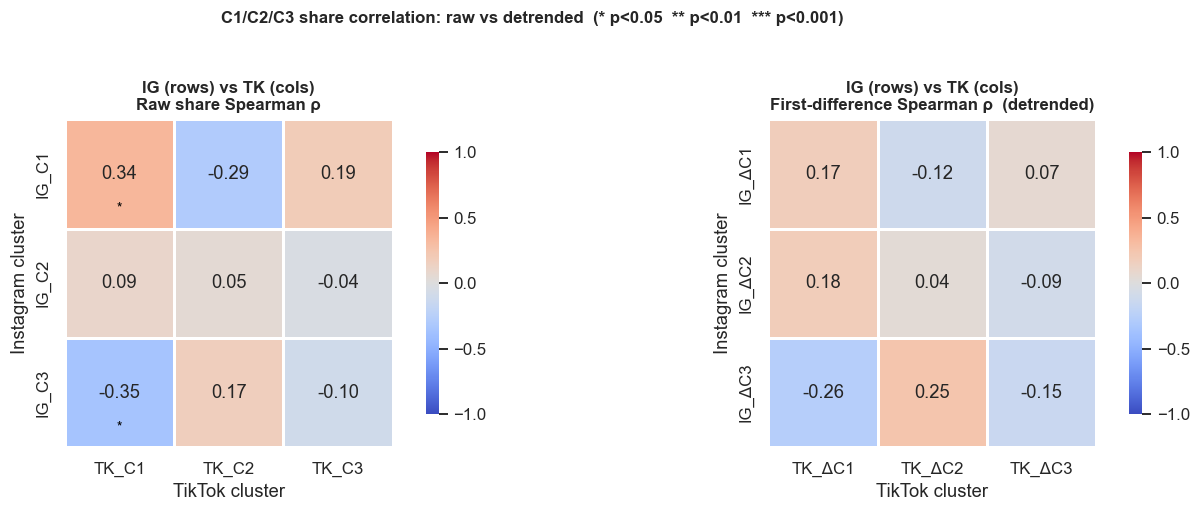

In [22]:
# ── Plot 3: Dual heatmaps — raw vs detrended Spearman (3×3 each) ─────────────
def pivot_corr(df, metric="spearman_rho"):
    return df.pivot(index="IG_col", columns="TK_col", values=metric).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, corr_df, title in [
    (axes[0], raw_corr,  "Raw share Spearman ρ"),
    (axes[1], diff_corr, "First-difference Spearman ρ  (detrended)"),
]:
    mat = pivot_corr(corr_df)
    # also overlay p-value markers
    p_mat = pivot_corr(corr_df, "spearman_p")
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, linewidths=.8, square=True, ax=ax,
                cbar_kws={"shrink": .8})
    # add significance stars
    for i, row in enumerate(mat.index):
        for j, col in enumerate(mat.columns):
            p = p_mat.loc[row, col]
            star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            if star:
                ax.text(j + 0.5, i + 0.82, star, ha="center", va="center",
                        fontsize=9, color="black")
    ax.set_title(f"IG (rows) vs TK (cols)\n{title}", fontweight="bold")
    ax.set_xlabel("TikTok cluster"); ax.set_ylabel("Instagram cluster")

fig.suptitle("C1/C2/C3 share correlation: raw vs detrended  (* p<0.05  ** p<0.01  *** p<0.001)",
             fontsize=11, fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "16_cluster_corr_heatmaps.png")
plt.show()

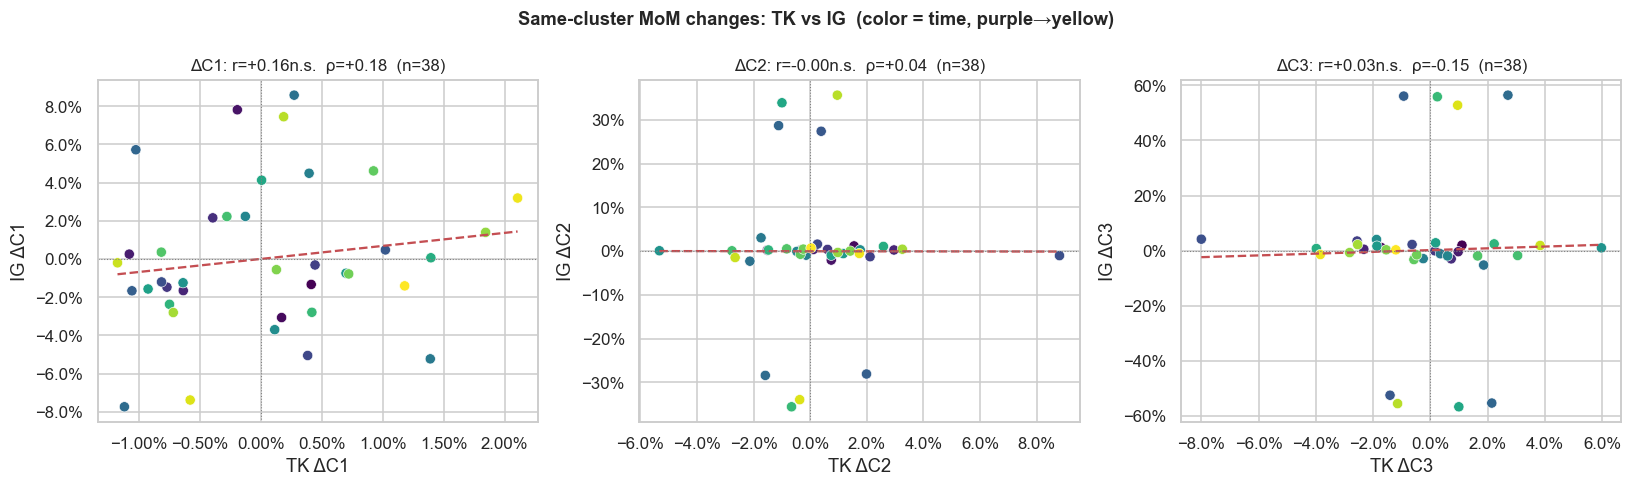

In [23]:
# ── Plot 4: Scatter plots — IG Δcluster vs TK Δcluster (same-name pairs) ─────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, CLUSTERS):
    x = diffs[f"TK_Δ{c}"]
    y = diffs[f"IG_Δ{c}"]
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    ax.scatter(x, y, c=range(len(x)), cmap="viridis", s=45, edgecolors="white", lw=0.4)
    # regression line
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr + b, "r--", lw=1.5)
    ax.axhline(0, color="gray", lw=0.7, ls=":"); ax.axvline(0, color="gray", lw=0.7, ls=":")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.set_xlabel(f"TK Δ{c}"); ax.set_ylabel(f"IG Δ{c}")
    sig = "***" if pp < 0.001 else "**" if pp < 0.01 else "*" if pp < 0.05 else "n.s."
    ax.set_title(f"Δ{c}: r={pr:+.2f}{sig}  ρ={sr:+.2f}  (n={len(x)})")

fig.suptitle("Same-cluster MoM changes: TK vs IG  (color = time, purple→yellow)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "17_scatter_delta_same_cluster.png")
plt.show()

## 9  Survival curves — time until permanent inactivity

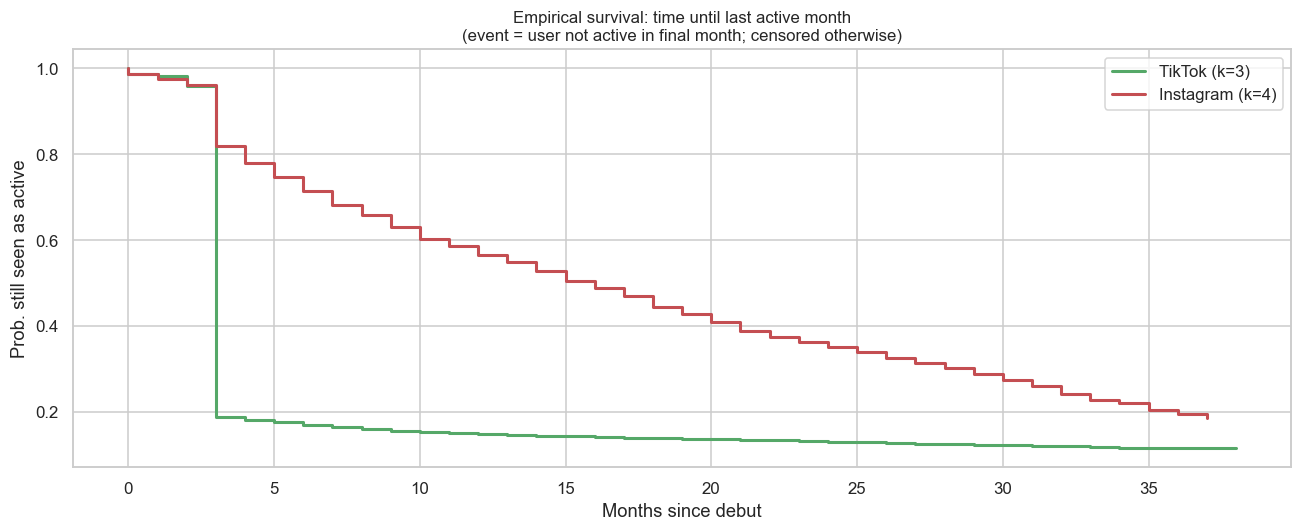

TikTok: median active span = 3 months | censored (still active at end) = 11.5%
Instagram: median active span = 11 months | censored (still active at end) = 18.7%


In [24]:
def time_to_permanent_inactive(df, id_col="user_key"):
    """For each user, count months from debut until last active month (right-censored at data end)."""
    rows = []
    max_month = df.month.max()
    for uid, grp in df.sort_values("month").groupby(id_col):
        active = grp[grp.state.str.startswith("C")]
        if len(active) == 0:
            continue
        debut = active.month.min()
        last  = active.month.max()
        span_months = round((last - debut).days / 30.44)
        event = int(last < max_month)  # 1 if observed inactive end, 0 if censored
        rows.append({"user_key": uid, "span_months": span_months, "event": event})
    return pd.DataFrame(rows)

tk_surv = time_to_permanent_inactive(tk)
ig_surv = time_to_permanent_inactive(ig)

# Kaplan-Meier style — naive empirical survival (ignoring censoring for simplicity)
def empirical_survival(surv_df):
    events = surv_df[surv_df.event == 1]["span_months"].sort_values()
    t = events.unique()
    n_total = len(surv_df)
    n_at_risk = n_total
    times, surv = [0], [1.0]
    for ti in t:
        n_events = (events == ti).sum()
        s = surv[-1] * (1 - n_events / n_at_risk)
        n_at_risk -= n_events
        times.append(ti); surv.append(s)
    return times, surv

tk_t, tk_s = empirical_survival(tk_surv)
ig_t, ig_s = empirical_survival(ig_surv)

fig, ax = plt.subplots(figsize=(12, 5))
ax.step(tk_t, tk_s, where="post", label=f"TikTok (k=3)", color="#55A868", lw=2)
ax.step(ig_t, ig_s, where="post", label=f"Instagram (k=4)", color="#C44E52", lw=2)
ax.set_xlabel("Months since debut"); ax.set_ylabel("Prob. still seen as active")
ax.set_title("Empirical survival: time until last active month\n(event = user not active in final month; censored otherwise)")
ax.legend(); fig.tight_layout(); save(fig, "13_survival.png"); plt.show()

for name, s in [("TikTok", tk_surv), ("Instagram", ig_surv)]:
    print(f"{name}: median active span = {s[s.event==1].span_months.median():.0f} months "
          f"| censored (still active at end) = {(s.event==0).mean()*100:.1f}%")

## 10  Summary findings

*(This cell is populated after execution — key numbers printed above are copied here.)*

**What to look for in each section:**

| Section | Key question |
|---|---|
| §2 Activity rate | How do the two platforms differ in churning / onboarding users over time? |
| §3 Cluster share | Which cluster dominates each platform and how stable is that composition? |
| §4 Debut timing | Was growth continuous or bursty? Do the two platforms share burst periods? |
| §5 Lifecycle | Are TK or IG users inherently more loyal (% of post-debut time active)? |
| §6 Entropy | Do users stay in one cluster (IG has 4 vs TK 3 — more room to switch)? |
| §7 Switch rate | Month-to-month cluster churn — rising or falling trend? |
| §8 Cross-platform | Does the shared-window active-% co-move? Spearman on first-differences answers if the link is genuine or a common trend. |
| §9 Survival | Which platform retains users longer? Median span comparison. |
